Descriptive Statistics:
count    181.000000
mean       0.047369
std        0.014185
min        0.028226
25%        0.037913
50%        0.041795
75%        0.053323
max        0.098630
Name: CO, dtype: float64
Epoch 1/50


/Users/sakdahomhuan/miniforge3/envs/udfire/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.0272 - val_loss: 0.1262
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0116 - val_loss: 0.0610
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0108 - val_loss: 0.0519
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0110 - val_loss: 0.0600
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0083 - val_loss: 0.0765
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0085 - val_loss: 0.0815
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0096 - val_loss: 0.0739
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0082 - val_loss: 0.0632
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0083 - val_loss: 0.0572
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0079 - val_loss: 0.0567
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0079 - val_loss: 0.0590
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0081 - val_loss: 0.0608
Epoch 13/50


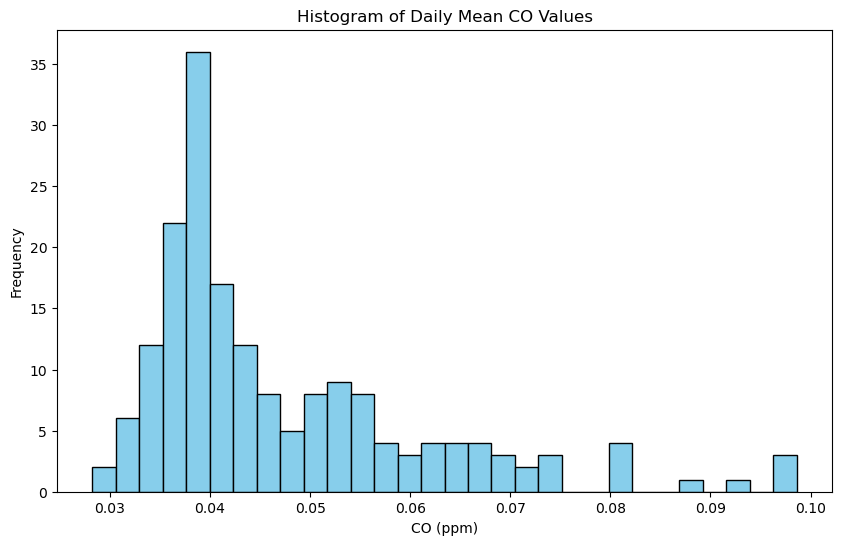

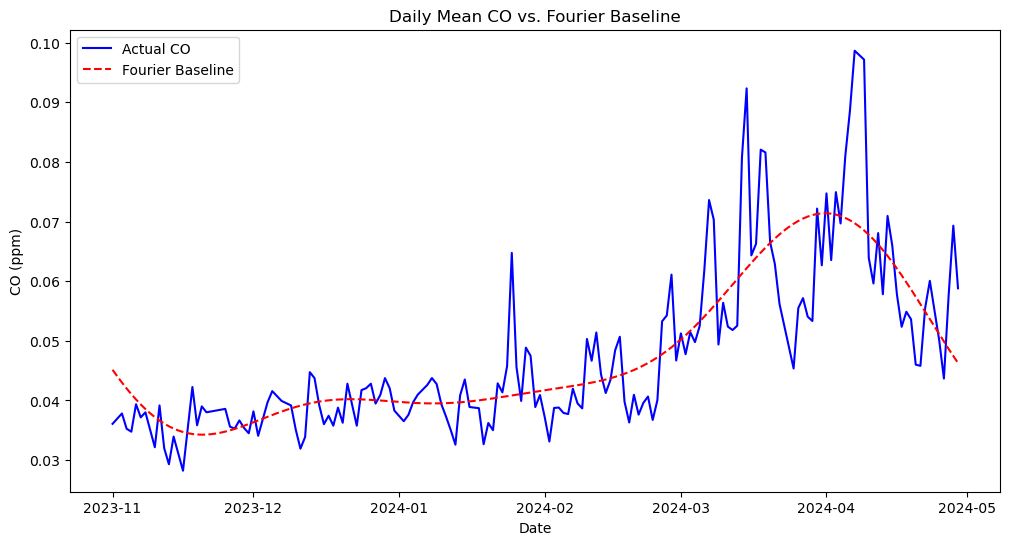

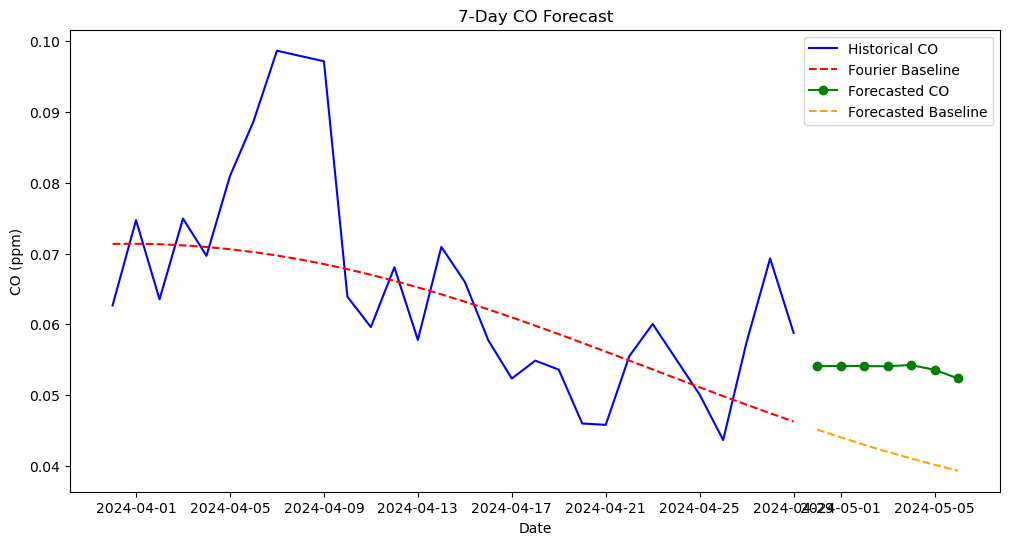

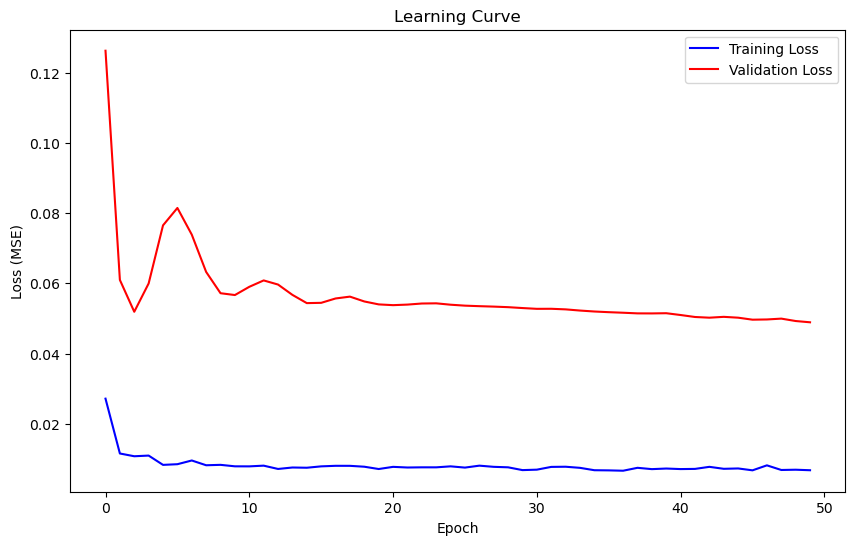

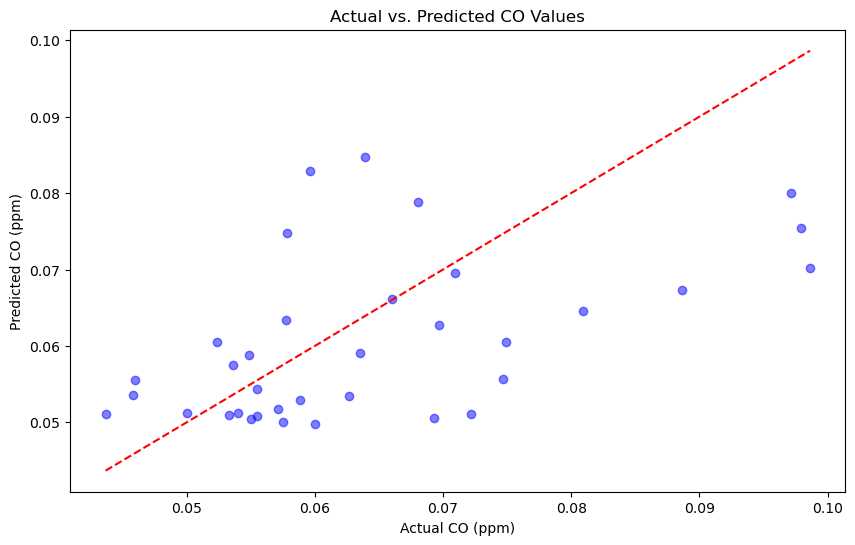


Plots saved: histogram_co.png, timeseries_baseline.png, forecast_co.png, learning_curve.png, actual_vs_predicted.png


In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from datetime import timedelta
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import uuid

# Setting random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Loading and preprocessing data
def load_and_preprocess_data():
    # Loading CSV data (assuming loadFileData is available; for this example, using pandas)
    # csv_data = loadFileData("CO_hex30_urban.csv")  # Uncomment if using loadFileData
    # For this example, assuming data is provided directly
    data = pd.read_csv('CO_hex30_urban.csv')  # Replace with loadFileData if needed

    # Converting date to datetime
    data['date'] = pd.to_datetime(data['date'])

    # Replacing 'NA' with NaN
    data['CO'] = data['CO'].replace('NA', np.nan).astype(float)

    # Grouping by date to get daily mean CO
    daily_data = data.groupby('date')['CO'].mean().reset_index()

    # Interpolating missing values
    daily_data['CO'] = daily_data['CO'].interpolate(method='linear')

    # Sorting by date
    daily_data = daily_data.sort_values('date')

    return daily_data

# Creating sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Fourier series function for baseline
def fourier_series(t, *a):
    result = a[0]  # Mean level
    for i in range(1, len(a), 2):
        freq = (i // 2) + 1
        result += a[i] * np.cos(2 * np.pi * freq * t) + a[i + 1] * np.sin(2 * np.pi * freq * t)
    return result

# Fitting Fourier baseline
def fit_fourier_baseline(dates, values, n_terms=3):
    t = np.arange(len(dates)) / len(dates)  # Normalized time
    initial_guess = [np.mean(values)] + [0] * (2 * n_terms)
    popt, _ = curve_fit(fourier_series, t, values, p0=initial_guess)
    baseline = fourier_series(t, *popt)
    return baseline, popt

# Building LSTM model
def build_lstm_model(seq_length):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(50),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Calculating metrics
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Main processing
daily_data = load_and_preprocess_data()

# Descriptive statistics
print("Descriptive Statistics:")
print(daily_data['CO'].describe())

# Normalizing CO values
scaler = MinMaxScaler()
co_values = daily_data['CO'].values.reshape(-1, 1)
co_scaled = scaler.fit_transform(co_values)

# Creating sequences
seq_length = 7
X, y = create_sequences(co_scaled, seq_length)

# Splitting into train and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Building and training the model
model = build_lstm_model(seq_length)
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predicting on test set
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_orig = scaler.inverse_transform(y_test)

# Calculating metrics
rmse, mae, r2 = calculate_metrics(y_test_orig, y_pred)
print(f"\nMetrics:\nRMSE: {rmse:.6f}\nMAE: {mae:.6f}\nR²: {r2:.6f}")

# Fitting Fourier baseline
baseline, popt = fit_fourier_baseline(daily_data['date'], daily_data['CO'])

# Forecasting 7 days
last_sequence = co_scaled[-seq_length:].reshape(1, seq_length, 1)
forecast_scaled = []
for _ in range(7):
    next_pred = model.predict(last_sequence, verbose=0)
    forecast_scaled.append(next_pred[0, 0])
    last_sequence = np.roll(last_sequence, -1, axis=1)
    last_sequence[0, -1, 0] = next_pred[0, 0]
forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1))

# Generating forecast dates
last_date = daily_data['date'].iloc[-1]
forecast_dates = [last_date + timedelta(days=i+1) for i in range(7)]

# Extending Fourier baseline for forecast
t_forecast = np.arange(len(daily_data), len(daily_data) + 7) / len(daily_data)
forecast_baseline = fourier_series(t_forecast, *popt)

# Plotting
import matplotlib.pyplot as plt
print(plt.style.available)

# 1. Histogram of daily mean CO values
plt.figure(figsize=(10, 6))
plt.hist(daily_data['CO'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Daily Mean CO Values')
plt.xlabel('CO (ppm)')
plt.ylabel('Frequency')
plt.show()

# 2. Time series with baseline
plt.figure(figsize=(12, 6))
plt.plot(daily_data['date'], daily_data['CO'], label='Actual CO', color='blue')
plt.plot(daily_data['date'], baseline, label='Fourier Baseline', color='red', linestyle='--')
plt.title('Daily Mean CO vs. Fourier Baseline')
plt.xlabel('Date')
plt.ylabel('CO (ppm)')
plt.legend()
plt.show()

# 3. 7-day forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_data['date'][-30:], daily_data['CO'][-30:], label='Historical CO', color='blue')
plt.plot(daily_data['date'][-30:], baseline[-30:], label='Fourier Baseline', color='red', linestyle='--')
plt.plot(forecast_dates, forecast, label='Forecasted CO', color='green', marker='o')
plt.plot(forecast_dates, forecast_baseline, label='Forecasted Baseline', color='orange', linestyle='--')
plt.title('7-Day CO Forecast')
plt.xlabel('Date')
plt.ylabel('CO (ppm)')
plt.legend()
plt.show()

# 4. Learning curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# 5. Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test_orig, y_pred, color='blue', alpha=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--')
plt.title('Actual vs. Predicted CO Values')
plt.xlabel('Actual CO (ppm)')
plt.ylabel('Predicted CO (ppm)')
plt.show()

print("\nPlots saved: histogram_co.png, timeseries_baseline.png, forecast_co.png, learning_curve.png, actual_vs_predicted.png")